['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']
Processing Class: Pepper__bell___Bacterial_spot
Pepper__bell___Bacterial_spot -> 997 images loaded
Processing Class: Pepper__bell___healthy
Pepper__bell___healthy -> 1478 images loaded
Processing Class: PlantVillage
PlantVillage -> 0 images loaded
Processing Class: Potato___Early_blight
Potato___Early_blight -> 1000 images loaded
Processing Class: Potato___healthy
Potato___healthy -> 152 images loaded
Processing Class: Potato___Late_blight
Potato___Late_blight -> 1000 images loaded
Processing Class: Tomato_Bacterial_spot
Tomato_Bacterial_spot -> 2127 images loaded
Proce

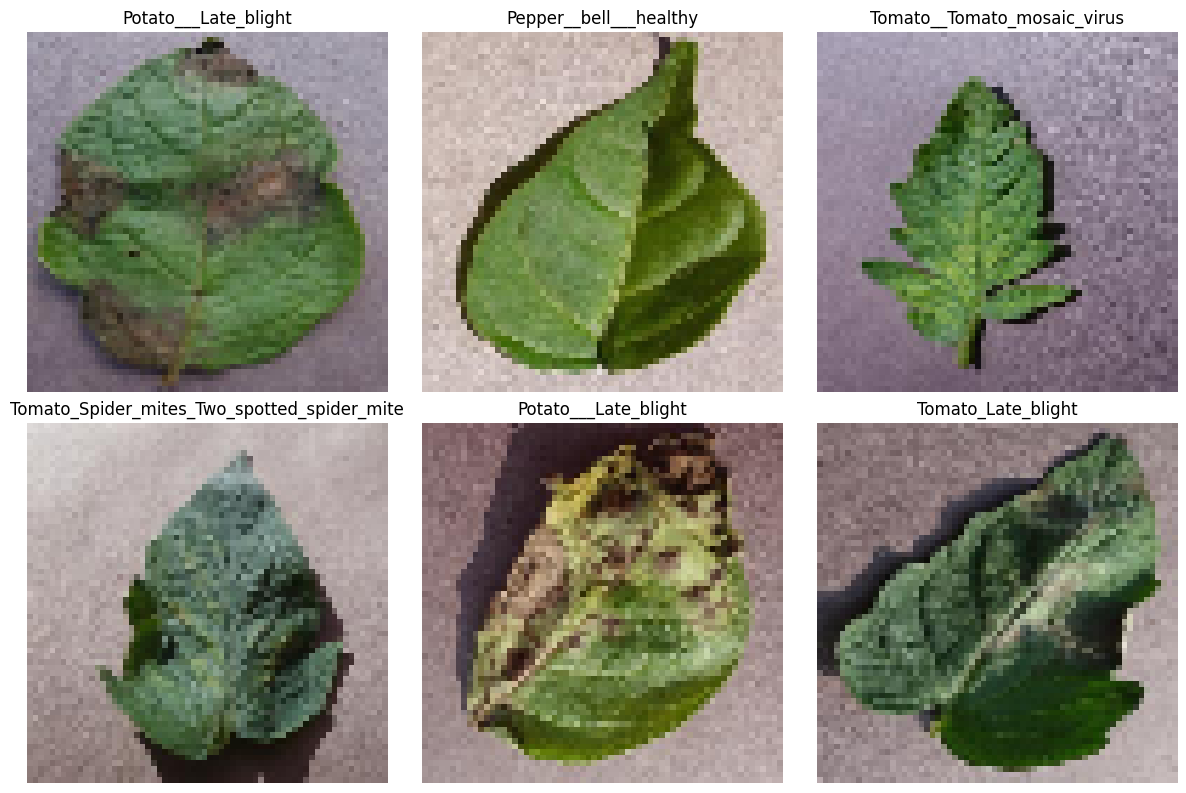

Week 1 Completed Successfully


In [1]:
# ================================
# Tomato Leaf Disease Detection
# Week 1 Complete Code
# ================================


# ================================
# Import Required Libraries
# ================================

import warnings
warnings.filterwarnings("ignore")

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator


# ================================
# Dataset Path and Image Size
# ================================

dataset_path = r"C:\Users\sreenath\OneDrive\Desktop\Internship\project 2\Data\archive\PlantVillage"

IMG_SIZE = 64


# ================================
# Initialize Empty Lists
# ================================

images = []
labels = []


# ================================
# Load Dataset Classes
# ================================

classes = os.listdir(dataset_path)

print(classes)


# ================================
# Load and Preprocess Images
# ================================

for cls in classes:

    print("Processing Class:", cls)

    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):

        image_count = 0

        for image_name in os.listdir(class_path):

            image_path = os.path.join(class_path, image_name)

            if image_name.lower().endswith(
                ('.jpg', '.jpeg', '.png', '.jfif')
            ):

                image = cv2.imread(image_path)

                if image is not None:

                    image = cv2.resize(
                        image,
                        (IMG_SIZE, IMG_SIZE)
                    )

                    image = cv2.cvtColor(
                        image,
                        cv2.COLOR_BGR2RGB
                    )

                    image = image.astype('float32') / 255.0

                    images.append(image)

                    labels.append(cls)

                    image_count += 1

        print(f"{cls} -> {image_count} images loaded")


print("Images Loaded Successfully")

print("Total Loaded Images:", len(images))


# ================================
# Check Unique Classes
# ================================

print(np.unique(labels))

print("Total Classes:",
      len(np.unique(labels)))


# ================================
# Convert Lists into NumPy Arrays
# ================================

images = np.array(images, dtype='float32')

labels = np.array(labels)

print("Total Images:", len(images))


# ================================
# Split Dataset into Train,
# Validation and Test
# ================================

X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Training Images :", len(X_train))

print("Validation Images :", len(X_val))

print("Testing Images :", len(X_test))


# ================================
# Apply Data Augmentation
# ================================

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

print("Data Augmentation Applied Successfully")


# ================================
# Save Preprocessed Dataset
# ================================

np.save("X_train.npy", X_train)

np.save("X_val.npy", X_val)

np.save("X_test.npy", X_test)

np.save("y_train.npy", y_train)

np.save("y_val.npy", y_val)

np.save("y_test.npy", y_test)

print("Dataset Saved Successfully")


# ================================
# Display Sample Images
# ================================

plt.figure(figsize=(12, 8))

for i in range(6):

    plt.subplot(2, 3, i + 1)

    plt.imshow(X_train[i])

    plt.title(y_train[i])

    plt.axis("off")

plt.tight_layout()

plt.show()


# ================================
# Completion Message
# ================================

print("Week 1 Completed Successfully")

In [2]:
# =========================================
# Tomato Leaf Disease Detection
# Week 2 Complete Code
# =========================================


# =========================================
# Import Required Libraries
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelEncoder


# =========================================
# Load Preprocessed Dataset
# =========================================

X_train = np.load("X_train.npy")

X_val = np.load("X_val.npy")

y_train = np.load("y_train.npy")

y_val = np.load("y_val.npy")

print("Datasets Loaded Successfully")


# =========================================
# Display Dataset Shapes
# =========================================

print("X_train Shape :", X_train.shape)

print("X_val Shape :", X_val.shape)

print("y_train Shape :", y_train.shape)

print("y_val Shape :", y_val.shape)


# =========================================
# Encode Labels
# =========================================

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_val_encoded = label_encoder.transform(
    y_val
)

print("Labels Encoded Successfully")


# =========================================
# Convert Labels to Categorical Format
# =========================================

print(np.unique(y_train_encoded))

num_classes = len(np.unique(y_train_encoded))

print("Number of Classes:", num_classes)

y_train_categorical = to_categorical(
    y_train_encoded,
    num_classes=num_classes
)

y_val_categorical = to_categorical(
    y_val_encoded,
    num_classes=num_classes
)

print("Categorical Conversion Completed")


# =========================================
# Build CNN Model
# =========================================

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,3)
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

print("CNN Layers Added Successfully")


# =========================================
# Add Flatten and Dense Layers
# =========================================

model.add(Flatten())

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(Dropout(0.5))

model.add(
    Dense(
        num_classes,
        activation='softmax'
    )
)

print("Dense and Dropout Layers Added Successfully")


# =========================================
# Display Model Summary
# =========================================

model.summary()


# =========================================
# Compile CNN Model
# =========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")


# =========================================
# Train CNN Model
# =========================================

history = model.fit(
    X_train,
    y_train_categorical,
    validation_data=(
        X_val,
        y_val_categorical
    ),
    epochs=10,
    batch_size=32
)


# =========================================
# Display Training History Keys
# =========================================

print(history.history.keys())


# =========================================
# Print Final Accuracy
# =========================================

train_accuracy = history.history[
    'accuracy'
][-1]

val_accuracy = history.history[
    'val_accuracy'
][-1]

print(
    "Final Training Accuracy :",
    train_accuracy
)

print(
    "Final Validation Accuracy :",
    val_accuracy
)


# =========================================
# Save Trained CNN Model
# =========================================

model.save(
    "tomato_leaf_disease_model.h5"
)

print("Model Saved Successfully")


# =========================================
# Completion Message
# =========================================

print("Week 2 Completed Successfully")

Datasets Loaded Successfully
X_train Shape : (14446, 64, 64, 3)
X_val Shape : (3096, 64, 64, 3)
y_train Shape : (14446,)
y_val Shape : (3096,)
Labels Encoded Successfully
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Number of Classes: 15
Categorical Conversion Completed
CNN Layers Added Successfully
Dense and Dropout Layers Added Successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │           1,935 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 685,135 (2.61 MB)

 Trainable params: 685,135 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Model Compiled Successfully
Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 39s 74ms/step - accuracy: 0.3009 - loss: 2.1472 - val_accuracy: 0.6974 - val_loss: 0.9309
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - accuracy: 0.6537 - loss: 1.0520 - val_accuracy: 0.7697 - val_loss: 0.6735
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.7385 - loss: 0.7987 - val_accuracy: 0.8379 - val_loss: 0.4663
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.7845 - loss: 0.6329 - val_accuracy: 0.8246 - val_loss: 0.4963
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8229 - loss: 0.5127 - val_accuracy: 0.8789 - val_loss: 0.3573
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8434 - loss: 0.4651 - val_accuracy: 0.8908 - val_loss: 0.3235
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.8688 - loss: 0.3912 - val_accuracy: 0.9005 - val_loss: 0.2874
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 34s 75ms/step - accura

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Final Training Accuracy : 0.9022566676139832
Final Validation Accuracy : 0.9050387740135193
Model Saved Successfully
Week 2 Completed Successfully


In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder


# Load Dataset
X_train = np.load("X_train.npy")
X_val = np.load("X_val.npy")

y_train = np.load("y_train.npy")
y_val = np.load("y_val.npy")

print("Dataset Loaded Successfully")


# Encode Labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

num_classes = len(np.unique(y_train_encoded))

y_train_categorical = to_categorical(
    y_train_encoded,
    num_classes=num_classes
)

y_val_categorical = to_categorical(
    y_val_encoded,
    num_classes=num_classes
)

print("Labels Encoded Successfully")


# Load MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)

print("Pre-trained MobileNetV2 Loaded")


# Freeze Base Layers
base_model.trainable = False

print("Base Layers Frozen Successfully")

Dataset Loaded Successfully
Labels Encoded Successfully
Pre-trained MobileNetV2 Loaded
Base Layers Frozen Successfully


In [24]:
# =========================================
# Build Transfer Learning Model
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder


# =========================================
# Load Dataset
# =========================================

X_train = np.load("X_train.npy")

X_val = np.load("X_val.npy")

y_train = np.load("y_train.npy")

y_val = np.load("y_val.npy")

print("Dataset Loaded Successfully")


# =========================================
# Encode Labels
# =========================================

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_val_encoded = label_encoder.transform(
    y_val
)

num_classes = len(
    np.unique(y_train_encoded)
)

y_train_categorical = to_categorical(
    y_train_encoded,
    num_classes=num_classes
)

y_val_categorical = to_categorical(
    y_val_encoded,
    num_classes=num_classes
)

print("Labels Encoded Successfully")


# =========================================
# Load MobileNetV2
# =========================================

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)

print("Pre-trained Model Loaded")


# =========================================
# Freeze Base Layers
# =========================================

base_model.trainable = False

print("Base Layers Frozen")


# =========================================
# Build Transfer Learning Model
# =========================================

model = Sequential()

model.add(base_model)

model.add(
    GlobalAveragePooling2D()
)

model.add(
    Dense(
        256,
        activation='relu'
    )
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        num_classes,
        activation='softmax'
    )
)

print("Custom Layers Added Successfully")


# =========================================
# Display Model Summary
# =========================================

model.summary()



Dataset Loaded Successfully
Labels Encoded Successfully
Pre-trained Model Loaded
Base Layers Frozen
Custom Layers Added Successfully


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 2, 2, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 15)                  │           1,935 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,620,751 (10.00 MB)

 Trainable params: 362,767 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
# =========================================
# Week 3 Day 3
# Compile and Train Model
# =========================================

from tensorflow.keras.optimizers import Adam


# =========================================
# Compile Model
# =========================================

model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")


# =========================================
# Train Model
# =========================================

history = model.fit(
    X_train,
    y_train_categorical,
    validation_data=(
        X_val,
        y_val_categorical
    ),
    epochs=10,
    batch_size=32
)

print("Model Training Completed Successfully")


# =========================================
# Display Training History Keys
# =========================================

print(history.history.keys())


# =========================================
# Print Final Accuracy
# =========================================

train_accuracy = history.history[
    'accuracy'
][-1]

val_accuracy = history.history[
    'val_accuracy'
][-1]

print(
    "Final Training Accuracy:",
    train_accuracy
)

print(
    "Final Validation Accuracy:",
    val_accuracy
)


# =========================================
# Completion Message
# =========================================

print("Week 3 Day 3 Completed Successfully")

Model Compiled Successfully
Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 84s 139ms/step - accuracy: 0.2045 - loss: 2.6990 - val_accuracy: 0.5568 - val_loss: 1.5979
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - accuracy: 0.4648 - loss: 1.7230 - val_accuracy: 0.6350 - val_loss: 1.2356
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.5671 - loss: 1.4049 - val_accuracy: 0.6702 - val_loss: 1.0688
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.6007 - loss: 1.2579 - val_accuracy: 0.6961 - val_loss: 0.9678
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.6324 - loss: 1.1427 - val_accuracy: 0.7138 - val_loss: 0.9030
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.6722 - loss: 1.0271 - val_accuracy: 0.7255 - val_loss: 0.8596
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.6882 - loss: 0.9694 - val_accuracy: 0.7348 - val_loss: 0.8173
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accur

In [1]:
# =========================================
# Tomato Leaf Disease Detection
# Week 4 Day 1
# Load Model and Test Dataset
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np

from tensorflow.keras.models import load_model

from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder


# =========================================
# Load Test Dataset
# =========================================

X_test = np.load("X_test.npy")

y_test = np.load("y_test.npy")

print("Test Dataset Loaded Successfully")


# =========================================
# Encode Labels
# =========================================

y_train = np.load("y_train.npy")

label_encoder = LabelEncoder()

label_encoder.fit(y_train)

y_test_encoded = label_encoder.transform(
    y_test
)

num_classes = len(
    np.unique(y_test_encoded)
)

y_test_categorical = to_categorical(
    y_test_encoded,
    num_classes=num_classes
)

print("Labels Encoded Successfully")


# =========================================
# Load Saved Model
# =========================================

model = load_model(
    "tomato_leaf_transfer_model.h5"
)

print("Model Loaded Successfully")


# =========================================
# Evaluate Model
# =========================================

loss, accuracy = model.evaluate(
    X_test,
    y_test_categorical
)

print(
    "Test Loss:",
    loss
)

print(
    "Test Accuracy:",
    accuracy
)


# =========================================
# Completion Message
# =========================================


Test Dataset Loaded Successfully
Labels Encoded Successfully


Model Loaded Successfully
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7606 - loss: 0.7586
Test Loss: 0.7079704403877258
Test Accuracy: 0.7713178396224976


Datasets Loaded Successfully
Labels Encoded Successfully


Model Loaded Successfully
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step
Prediction Completed Successfully
[[118  20   1   2   0   1   1   4   1   0   0   0   1   0   0]
 [  5 214   0   0   0   1   0   0   0   0   0   1   0   0   0]
 [  0   1 141   3   1   1   0   1   0   0   0   1   0   0   1]
 [  1   2   9 115   3   7   3   8   0   0   0   0   1   0   1]
 [  0   1   0   5  14   0   0   0   0   0   2   0   0   0   1]
 [  0   1   0   1   0 288   2  10   0   5   0   2  10   0   0]
 [  1   1   4   0   0  10  72  22   6  10   1  10   9   0   4]
 [  9   2   5  10   0   8  20 195  13  12   3   3   5   1   1]
 [  1   0   0   1   0   8   2  13  86  12   6   5   7   0   2]
 [  2   4   4   4   0  29   2  22  16 157   4  13   3   3   3]
 [  1   1   1   2   0   5   3   1   0   4 194  13  13   5   9]
 [  1   1   2   2   1  11   2   2   2   9  31 113   3   0  30]
 [  1   1   0   0   0  21   2   7   1   1   6   1 436   3   2]
 [  0   0   0   0   0   0   0   0   7   7   3   0  10  29   0]
 [  0   0   0   0 

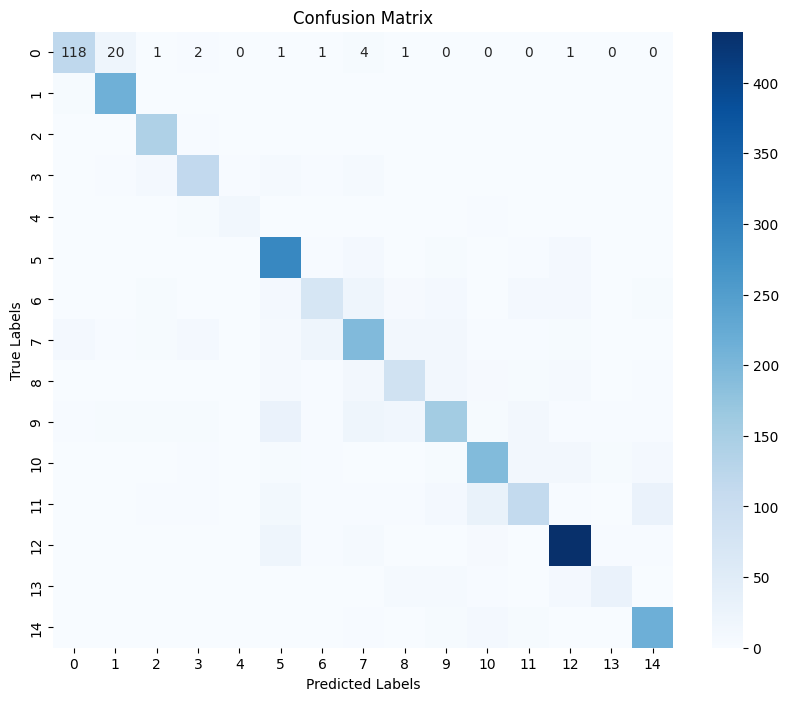

In [3]:
# =========================================
# Tomato Leaf Disease Detection
# Week 4 Day 2
# Generate Confusion Matrix
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import confusion_matrix

import seaborn as sns


# =========================================
# Load Test Dataset
# =========================================

X_test = np.load("X_test.npy")

y_test = np.load("y_test.npy")

y_train = np.load("y_train.npy")

print("Datasets Loaded Successfully")


# =========================================
# Encode Labels
# =========================================

label_encoder = LabelEncoder()

label_encoder.fit(y_train)

y_test_encoded = label_encoder.transform(
    y_test
)

print("Labels Encoded Successfully")


# =========================================
# Load Saved Model
# =========================================

model = load_model(
    "tomato_leaf_transfer_model.h5"
)

print("Model Loaded Successfully")


# =========================================
# Predict Test Data
# =========================================

y_pred = model.predict(
    X_test
)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

print("Prediction Completed Successfully")


# =========================================
# Generate Confusion Matrix
# =========================================

cm = confusion_matrix(
    y_test_encoded,
    y_pred_classes
)

print(cm)


# =========================================
# Plot Confusion Matrix
# =========================================

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.title("Confusion Matrix")

plt.show()


# =========================================
# Completion Message
# =========================================


In [4]:
# =========================================
# Tomato Leaf Disease Detection
# Week 4 Day 3
# Generate Classification Report
# =========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np

from tensorflow.keras.models import load_model

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report


# =========================================
# Load Test Dataset
# =========================================

X_test = np.load("X_test.npy")

y_test = np.load("y_test.npy")

y_train = np.load("y_train.npy")

print("Datasets Loaded Successfully")


# =========================================
# Encode Labels
# =========================================

label_encoder = LabelEncoder()

label_encoder.fit(y_train)

y_test_encoded = label_encoder.transform(
    y_test
)

print("Labels Encoded Successfully")


# =========================================
# Load Saved Model
# =========================================

model = load_model(
    "tomato_leaf_transfer_model.h5"
)

print("Model Loaded Successfully")


# =========================================
# Predict Test Data
# =========================================

y_pred = model.predict(
    X_test
)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

print("Prediction Completed Successfully")


# =========================================
# Generate Classification Report
# =========================================

report = classification_report(
    y_test_encoded,
    y_pred_classes,
    target_names=label_encoder.classes_
)

print(report)


# =========================================
# Completion Message
# =========================================


Datasets Loaded Successfully
Labels Encoded Successfully


Model Loaded Successfully
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step
Prediction Completed Successfully
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.84      0.79      0.82       149
                     Pepper__bell___healthy       0.86      0.97      0.91       221
                      Potato___Early_blight       0.84      0.94      0.89       150
                       Potato___Late_blight       0.79      0.77      0.78       150
                           Potato___healthy       0.74      0.61      0.67        23
                      Tomato_Bacterial_spot       0.74      0.90      0.81       319
                        Tomato_Early_blight       0.65      0.48      0.55       150
                         Tomato_Late_blight       0.68      0.68      0.68       287
                           Tomato_Leaf_Mold       0.65      0.60      0.62       143
                  Tomato_Septoria_leaf_spot      